# Fase 8-10: Preprocessing, feature engineering y feature selection

## 8. Preprocessing seguro

- Limpieza base (fases 2-3): solo días hábiles, forward-fill, features con cobertura suficiente → `data/interim`.
- **Escalado (RobustScaler) ajustado SOLO con train** y aplicado con `transform` a val/test.
- No hay imputación con estado: el ffill ya usa solo pasado.

## 9. Feature engineering (serie temporal)

- **Lags del target:** 1, 2, 3, 5, 10, 21 (días hábiles).
- **Retornos logarítmicos** del target a esos lags.
- **Rolling:** retorno y media/desv. móvil a 5, 21, 63, 126 días.
- **Exógenas:** lag 1 de cada una + retorno log del lag (siempre positivas).
- **Calendario:** año, mes, día de semana, trimestre, día del año.
- **Indicadores de ausencia:** si la exógena faltaba en origen, marca 1/0.

Todas las ventanas miran **solo hacia atrás** (sin futuro) → sin leakage.

## 10. Feature selection

- **Reglas:** se eliminan features excluidas por cobertura (config) y el target/date.
- **Filtro:** correlación de Pearson; si dos features correlacionan >0.98, se elimina una.
- **Embedded (fase 15):** importancia de XGBoost para el informe.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de features y verificación de integridad.

Comprobamos que no hay NaNs en train (el warm-up ya los eliminó) y que el
número de features es el esperado (146 brutas).

In [2]:
import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split
from src.features.build_features import get_feature_columns
from src.utils import path_from_root

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)

feat_cols = get_feature_columns(feats, cfg["target"]["horizons"])
print("Features totales:", len(feat_cols))

X_train = parts["train"][feat_cols].to_numpy(dtype=np.float64)
print("NaN en train (features):", np.isnan(X_train).sum())
assert not np.isnan(X_train).any(), "Hay NaNs en train"

Features totales: 186
NaN en train (features): 0


Preprocesador ajustado SOLO con train.

RobustScaler (percentiles 5-95) reduce el impacto de outliers. El `fit` se
hace únicamente con train; val/test usan `transform` (nunca refit).

In [3]:
from src.models.pipeline import fit_preprocessor

pp = fit_preprocessor(X_train)
print("Preprocesador ajustado en train:", type(pp[0]).__name__)

Preprocesador ajustado en train: RobustScaler


Selección por correlación (redundancia > 0.98).

Buscamos pares de features con |ρ| > 0.98 (colinealidad extrema). De cada
par eliminamos el miembro con menor varianza, priorizando conservar los
niveles (sin sufijo _lag1) frente a sus lags/retornos.

In [4]:
corr = parts["train"][feat_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high = [(upper.columns[i], upper.columns[j], round(upper.iloc[i, j], 3))
        for i in range(len(upper)) for j in range(i + 1, len(upper))
        if upper.iloc[i, j] > 0.98]
print(f"Pares con correlación > 0.98: {len(high)}")
for a, b, v in high[:15]:
    print(f"  {a} ~ {b}: {v}")

def _priority(c: str) -> int:
    """Prioridad: 0 = derivada (lag/retorno), 1 = nivel base."""
    return 0 if c.endswith(("_lag1", "_ret_lag1")) else 1

drop_set = set()
for a, b, _ in high:
    if _priority(a) != _priority(b):
        drop_set.add(a if _priority(a) < _priority(b) else b)
    else:
        va, vb = parts["train"][a].var(), parts["train"][b].var()
        drop_set.add(a if va <= vb else b)

sel_cols = [c for c in feat_cols if c not in drop_set]
print(f"\nFeatures tras filtro de redundancia: {len(feat_cols)} -> {len(sel_cols)}")
print("Eliminadas:", sorted(drop_set))

Pares con correlación > 0.98: 254
  us10y_yield ~ us10y_yield_lag1: 0.999
  usdjpy_exchange ~ usdjpy_exchange_lag1: 0.999
  silver_futures ~ silver_spot: 1.0
  silver_futures ~ silver_futures_lag1: 0.999
  silver_futures ~ silver_spot_lag1: 0.999
  eurusd_exchange ~ eurusd_exchange_lag1: 0.999
  gold_futures ~ export_price_index: 0.994
  gold_futures ~ gold_spot_lag1: 1.0
  gold_futures ~ gold_spot_lag2: 0.999
  gold_futures ~ gold_spot_lag3: 0.999
  gold_futures ~ gold_spot_lag5: 0.998
  gold_futures ~ gold_spot_lag10: 0.997
  gold_futures ~ gold_spot_lag21: 0.994
  gold_futures ~ gold_rollmean_5: 1.0
  gold_futures ~ gold_rollmean_21: 0.998

Features tras filtro de redundancia: 186 -> 110
Eliminadas: ['brent_futures', 'brent_futures_lag1', 'brent_spot_lag1', 'commodities_bloomberg_lag1', 'commodities_crb_lag1', 'consumer_confidence_lag1', 'consumer_confidence_missing', 'copper_futures', 'copper_futures_lag1', 'copper_spot_lag1', 'copper_spot_missing', 'credit_spread_lag1', 'dxy_futur

Guardado de la lista de features seleccionadas.

Esta lista (85 features) es un artefacto clave: la API y el CLI la usan
para validar entradas y construir el vector en el orden exacto de
entrenamiento.

In [5]:
import json

from src.utils import path_from_root

out_path = path_from_root("models", "feature_list.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(sel_cols, f, indent=2)
print(f"Lista de features guardada en {out_path} ({len(sel_cols)})")

Lista de features guardada en C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\feature_list.json (110)


Visualización de la reducción de features.

Gráfico de barras con el número de features antes/después del filtro de
redundancia, y un heatmap de correlación de las 85 features finales para
verificar que no quedan pares extremadamente colineales.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\feature_selection.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/feature_selection.png')

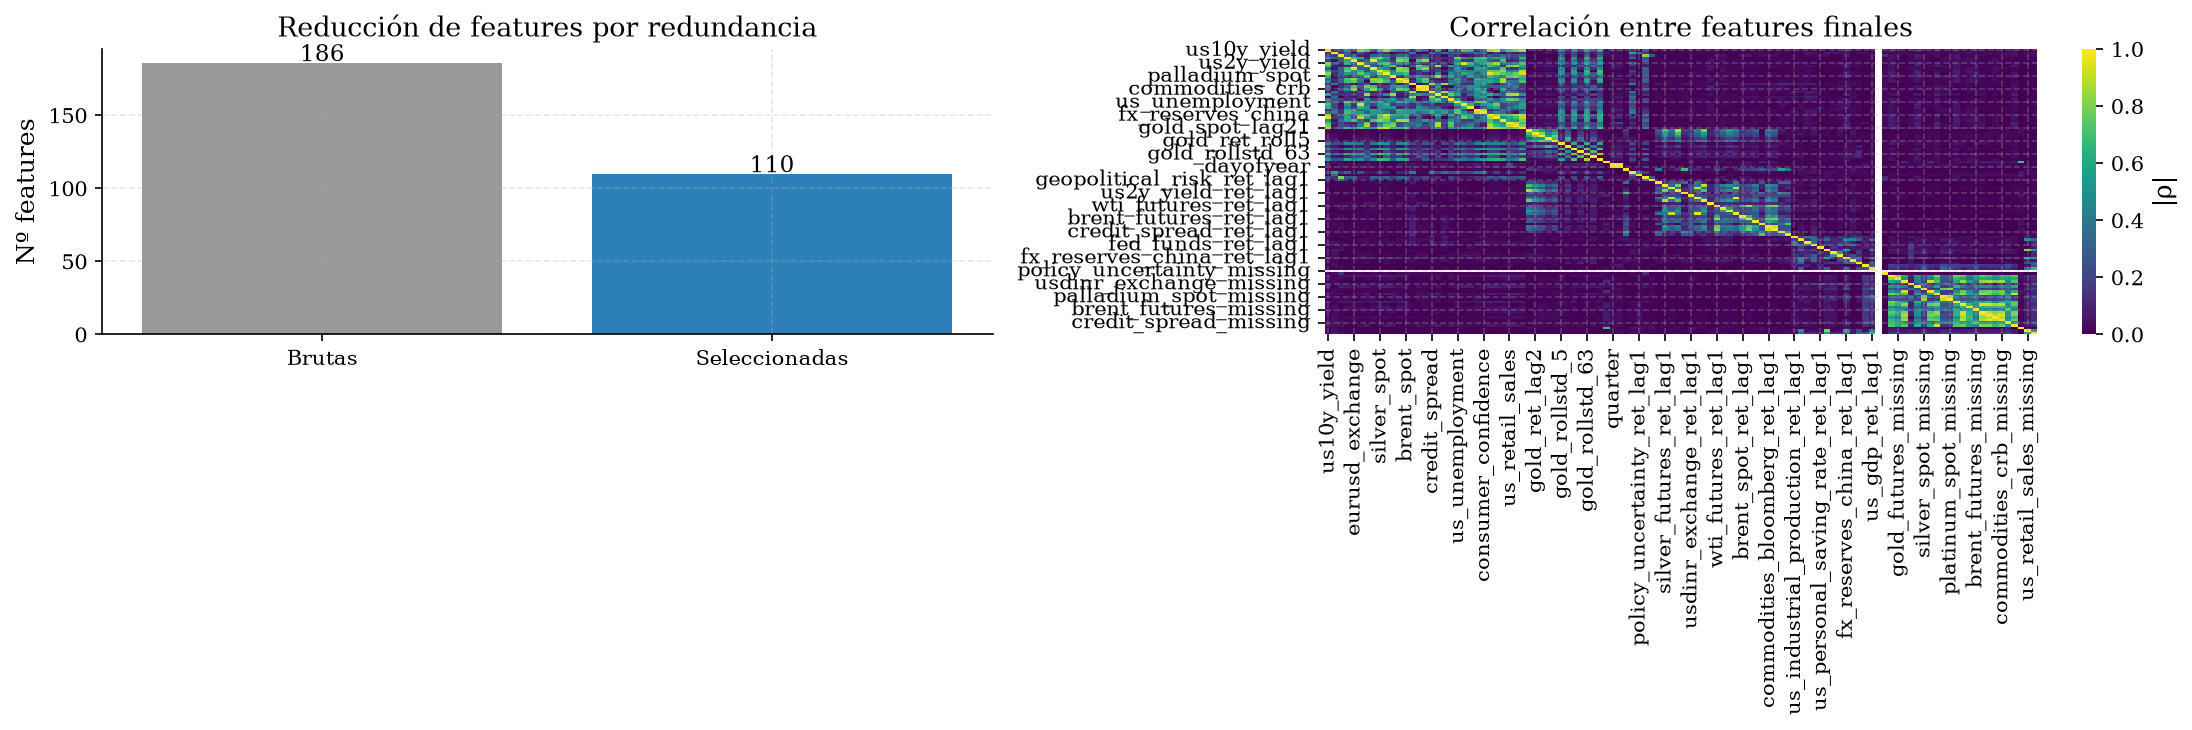

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(["Brutas", "Seleccionadas"], [len(feat_cols), len(sel_cols)],
            color=["#999", "#2c7fb8"])
axes[0].set_title("Reducción de features por redundancia")
axes[0].set_ylabel("Nº features")
for i, v in enumerate([len(feat_cols), len(sel_cols)]):
    axes[0].text(i, v + 1, str(v), ha="center")

corr_final = parts["train"][sel_cols].corr().abs()
sns.heatmap(corr_final, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
            cbar_kws={"label": "|ρ|"})
axes[1].set_title("Correlación entre features finales")
plt.tight_layout()

from src.utils import save_fig
save_fig(fig, "feature_selection.png")